## Imports

In [1]:
import os
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm

# At the very beginning of the code, before calling model_function
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## Downloading datasets

In [2]:
model_df = pd.read_pickle("pkls/model_df_full")
factors = pd.read_pickle("pkls/factors_full")

## Feature engineering

In [3]:
def get_feature_metadata(feat_name):
    """
    Returns (Description, Group) using a two-level hierarchy: {category}.{source}.
    Categories: memory, momentum, relative, channels, volatility, trend, 
                cross_asset, tails, fractal, seasonal, spread, stationarity, logistics.
    Sources: price, macro, commodity, currency, freight, volume, supply_demand, or combined (e.g. price_freight).
    """
        # Add these inside get_feature_metadata(feat_name):
    if '_vola_vol_prod_' in feat_name:
        return "Volatility and volume synergy interaction", "volatility.combined"
    if 'mom_spread_' in feat_name:
        return "Cross-asset momentum divergence spread", "momentum.cross_asset"
    if '_breakout_' in feat_name:
        return "Historical channel high/low breakout flag", "tails.price"
    if '_cum_flow_' in feat_name:
        return "Cumulative rolling position flow accumulation", "volume.positions"
    if '_log_ret_' in feat_name and any(f"{i}w" in feat_name for i in [1, 2, 4, 12, 52]):
        return "Multi-period logarithmic return trend", f"stationarity.{_extract_source(feat_name)}"
    
    def _extract_source(name):
        # Maps short prefixes to semantic source names
        prefix_map = {'pr': 'price', 'e': 'indexes', 'c': 'commodity', 
                      '$': 'currency', 'b': 'freight', 'v': 'volume', 
                      'sd': 'supply_demand', "fp": "futures_positions"}
        for p, src in prefix_map.items():
            if name.startswith(p + '_') or name.startswith(p):
                return src
        return 'technical'

    # 1. Memory / Lags
    if '_lag_' in feat_name:
        window = feat_name.split('_lag_')[-1]
        return f"Lag {window} periods", f"memory.{_extract_source(feat_name)}"
    
    # 2. Momentum
    if '_diff_1_smooth' in feat_name:
        return "Smoothed momentum (4w MA)", f"momentum.{_extract_source(feat_name)}"
    if '_diff_' in feat_name:
        window = feat_name.split('_diff_')[-1]
        return f"Difference over {window} periods", f"momentum.{_extract_source(feat_name)}"
    if '_accel' in feat_name:
        return "Momentum acceleration (2nd diff)", f"momentum.{_extract_source(feat_name)}"
    
    # 3. Relative Strength / Ratios
    if '_div_' in feat_name:
        parts = feat_name.split('_div_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Relative strength ratio", f"relative.{source}"
    
    # 4. Channels & Levels
    if '_rel_pos_' in feat_name:
        window = feat_name.split('_rel_pos_')[-1]
        return f"Relative position in {window}w range [0-1]", f"channels.{_extract_source(feat_name)}"
    if '_dist_sma_' in feat_name:
        window = feat_name.split('_dist_sma_')[-1]
        return f"Distance to {window}w SMA", f"channels.{_extract_source(feat_name)}"
    if '_sma_pct_' in feat_name:
        window = feat_name.split('_sma_pct_')[-1]
        return f"{window}w SMA slope (% change)", f"channels.{_extract_source(feat_name)}"
    
    # 5. Volatility
    if '_spread_' in feat_name:
        window = feat_name.split('_spread_')[-1]
        return f"Range spread vs SMA ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_zscore_' in feat_name:
        window = feat_name.split('_zscore_')[-1]
        return f"Z-score ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_ann_vol_' in feat_name:
        window = feat_name.split('_ann_vol_')[-1]
        return f"Annualized volatility ({window}w)", f"volatility.{_extract_source(feat_name)}"
    if '_vol_pct_' in feat_name:
        window = feat_name.split('_vol_pct_')[-1]
        return f"Volatility % change ({window}w)", f"volatility.{_extract_source(feat_name)}"
    
    # 6. Trend Health
    if '_up_weeks_' in feat_name:
        return "Count of up weeks (12w)", "trend.price"
    if '_er_' in feat_name:
        return "Efficiency ratio (trend purity)", "trend.price"
    
    # 7. Cross-Asset Correlations
    if '_corr_' in feat_name:
        parts = feat_name.split('_corr_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1].split('_')[0]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Rolling correlation (13w)", f"cross_asset.{source}"
    
    # 8. Tails & Extremes
    if '_weeks_since_max' in feat_name:
        return "Weeks since rolling high (52w)", f"tails.{_extract_source(feat_name)}"
    if '_is_outlier' in feat_name:
        return "Outlier flag (|Z| > 2.5)", f"tails.{_extract_source(feat_name)}"
    
    # 9. Fractality
    if '_fractal_dim' in feat_name:
        return "Fractal dimension / Hurst proxy", "fractal.price"
    
    # 10. Seasonality
    if '_exp_mean_month' in feat_name:
        return "Expanding seasonal mean by month", "seasonal.price"
    
    # 11. Spread Dynamics
    if '_conv' in feat_name and '_vs_' in feat_name:
        parts = feat_name.split('_vs_')
        src_a = _extract_source(parts[0])
        src_b = _extract_source(parts[1].split('_')[0]) if len(parts) > 1 else 'other'
        source = f"{src_a}_{src_b}" if src_a != src_b else src_a
        return "Convergence rate (4w price diff)", f"spread.{source}"
    
    # 12. Logistics & Delta Features
    if 'delta_log_ret_' in feat_name:
        return "Log return spread (delta)", "logistics.freight_price"
    if 'logistics_cost_pressure_' in feat_name:
        return "Logistics cost pressure (freight/price)", "logistics.freight_price"
    
    # 13. Stationarity
    if '_log_ret' in feat_name:
        return "Logarithmic return", f"stationarity.{_extract_source(feat_name)}"
    
    # Fallback
    return "Derived feature", f"technical.{_extract_source(feat_name)}"

In [5]:
def generate_all_features(df_input, original_factors=None):
    """Generates technical, macro, cross-asset, and synergy features.

    Protects against data leakage via chronological shifting, optimizes
    memory usage to prevent fragmentation, and seamlessly integrates
    multi-period log returns and asset interaction vectors.
    """
    import pandas as pd
    import numpy as np
    
    # 0. Chronological sorting and basic preparation
    df = df_input.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    cols = df.columns
    pr_cols = [c for c in cols if c.startswith("pr")]
    e_cols = [c for c in cols if c.startswith("e")]
    c_cols = [c for c in cols if c.startswith("c")]
    b_cols = [c for c in cols if c.startswith("b")]
    v_cols = [c for c in cols if c.startswith("v")]
    curr_cols = [c for c in cols if c.startswith("$")]
    fp_cols = [c for c in cols if c.startswith("fp")]
    sd_cols = [c for c in cols if c.startswith("sd")]

    # Analytical rolling horizons
    windows_lag = (1, 2, 3, 4, 12, 52)
    windows_diff = (1, 4, 52)
    windows_extended = (12, 52, 104)

    # Sanitize price-like metrics to protect log conversions
    price_likes = pr_cols + e_cols + c_cols + curr_cols
    for col in price_likes:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: x if x > 0 else np.nan).ffill()

    # Separate feature groups
    univariate_cols = (
        e_cols + c_cols + b_cols + v_cols + curr_cols + fp_cols + sd_cols
    )
    cross_asset_base_cols = pr_cols
    price_factors = e_cols + c_cols + curr_cols + b_cols

    # High-performance accumulator map
    new_features = {}

    def in_all(col_list):
        all_features = (
            pr_cols + e_cols + c_cols + b_cols + v_cols + curr_cols + sd_cols
        )
        return [c for c in col_list if c in all_features]

    # =====================================================================
    # 🌟 TARGET CONFIGURATION (Next week's log return forecasting)
    # =====================================================================
    df["pr_next"] = df["pr"].shift(-1)
    new_features["target_log_return"] = np.log(df["pr_next"] / df["pr"])

    # 🧠 Memory (Lags)
    for col in univariate_cols:
        for lag in windows_lag:
            new_features[f"{col}_lag_{lag}"] = df[col].shift(lag)

    # 🚀 Momentum
    for col in univariate_cols:
        diff_1 = df[col].diff(1)
        new_features[f"{col}_diff_1"] = diff_1
        for diff in windows_diff:
            new_features[f"{col}_diff_{diff}"] = df[col].diff(diff)
        new_features[f"{col}_accel"] = diff_1 - diff_1.shift(1)
        new_features[f"{col}_diff_1_smooth"] = diff_1.rolling(window=4).mean()

    # ⚖️ Relative Strength (Level Ratios)
    for pr in in_all(cross_asset_base_cols):
        for e in in_all(e_cols):
            new_features[f"{pr}_div_{e}"] = df[pr] / df[e]
        for c in in_all(c_cols):
            new_features[f"{pr}_div_{c}"] = df[pr] / df[c]
        for b in in_all(b_cols):
            new_features[f"{pr}_div_{b}"] = df[pr] / df[b]
        for cur in in_all(curr_cols):
            new_features[f"{pr}_div_{cur}"] = df[pr] / df[cur]

    # 📊 Channels & Levels
    for col in univariate_cols:
        for window in windows_extended:
            r_min = df[col].rolling(window).min()
            r_max = df[col].rolling(window).max()
            r_mean = df[col].rolling(window).mean()
            new_features[f"{col}_rel_pos_{window}"] = (
                (df[col] - r_min) / (r_max - r_min + 1e-9)
            )
            new_features[f"{col}_dist_sma_{window}"] = df[col] - r_mean
            new_features[f"{col}_sma_pct_{window}"] = (
                r_mean.pct_change(periods=1)
            )

    # 📉 Volatility Structure
    for col in univariate_cols:
        for window in windows_extended:
            r_min = df[col].rolling(window).min()
            r_max = df[col].rolling(window).max()
            r_mean = df[col].rolling(window).mean()
            r_std = df[col].rolling(window).std()
            new_features[f"{col}_spread_{window}"] = (
                (r_max - r_min) / (r_mean + 1e-9)
            )
            new_features[f"{col}_zscore_{window}"] = (
                (df[col] - r_mean) / (r_std + 1e-9)
            )
            new_features[f"{col}_ann_vol_{window}"] = r_std * np.sqrt(52)
            new_features[f"{col}_vol_pct_{window}"] = (
                r_std.pct_change(periods=1)
            )

    # 🩺 Trend Purity
    for col in in_all(pr_cols):
        is_up = (df[col].diff(1) > 0).astype(int)
        new_features[f"{col}_up_weeks_12"] = is_up.rolling(window=12).sum()
        total_move = abs(df[col] - df[col].shift(12))
        sum_abs_moves = df[col].diff(1).abs().rolling(window=12).sum()
        new_features[f"{col}_er_12"] = total_move / (sum_abs_moves + 1e-9)

    # 🔗 Rolling Cross-Asset Correlations
    for pr in in_all(cross_asset_base_cols):
        for c in in_all(c_cols):
            new_features[f"{pr}_corr_{c}_13"] = (
                df[pr].rolling(window=13).corr(df[c])
            )
        for cur in in_all(curr_cols):
            new_features[f"{pr}_corr_{cur}_13"] = (
                df[pr].rolling(window=13).corr(df[cur])
            )

    # 💥 Distribution Tails & Extremes (Vectorized Optimization)
    for col in in_all(pr_cols) + in_all(curr_cols) + in_all(e_cols):
        rolling_max_idx = (
            df[col]
            .rolling(window=52)
            .apply(lambda x: np.argmax(x), raw=True)
            .astype(float)
        )
        new_features[f"{col}_weeks_since_max"] = 52 - 1 - rolling_max_idx

        r_mean = df[col].rolling(window=52).mean()
        r_std = df[col].rolling(window=52).std()
        z = (df[col] - r_mean) / (r_std + 1e-9)
        new_features[f"{col}_is_outlier"] = (z.abs() > 2.5).astype(int)

    # 🌀 Fractality
    for col in in_all(pr_cols):
        high_low = (
            df[col].rolling(window=12).max() - df[col].rolling(window=12).min()
        )
        sum_daily_range = (
            (df[col] - df[col].shift(1)).abs().rolling(window=12).sum()
        )
        new_features[f"{col}_fractal_dim"] = high_low / (
            sum_daily_range + 1e-9
        )

    # 📆 Expanding Seasonal Means
    df["Month"] = df["Date"].dt.month
    for col in in_all(pr_cols):
        new_features[f"{col}_exp_mean_month"] = (
            df.groupby("Month")[col]
            .transform(lambda x: x.expanding().mean().shift(1))
        )

    # 🎚️ Spread Dynamics
    for pr in in_all(cross_asset_base_cols):
        for c in in_all(c_cols):
            new_features[f"{pr}_vs_{c}_conv"] = (
                df[pr].pct_change(4) - df[c].pct_change(4)
            )

    # =====================================================================
    # 🌟 MULTI-PERIOD LOG RETURNS FOR MARKET PRICE FACTORS
    # =====================================================================
    for col in price_factors:
        if col in df.columns:
            # Wrap in context manager to suppress log zero/negative runtime warnings
            with np.errstate(invalid="ignore"):
                new_features[f"{col}_log_ret_1w"] = np.log(
                    df[col] / df[col].shift(1)
                )
                for horizon in (2, 4, 12, 52):
                    new_features[f"{col}_log_ret_{horizon}w"] = np.log(
                        df[col] / df[col].shift(horizon)
                    )

    # 📏 Stationary Log Returns (Current Week Basis for other variables)
    for col in univariate_cols:
        if col in fp_cols and df[col].min() < 0:
            continue
        if col in price_factors:
            continue
        with np.errstate(invalid="ignore"):
            new_features[f"{col}_log_ret"] = np.log(df[col] / df[col].shift(1))

    # 🚢 Logistics cost pressures
    for b in in_all(b_cols):
        for pr in in_all(cross_asset_base_cols):
            with np.errstate(invalid="ignore"):
                pr_log = np.log(df[pr] / df[pr].shift(1))
                b_log = np.log(df[b] / df[b].shift(1))
            new_features[f"delta_log_ret_{b}_vs_{pr}"] = b_log - pr_log
            new_features[f"logistics_cost_pressure_{b}_{pr}"] = df[b] / df[pr]

    # =====================================================================
    # 🌟 ADVANCED FEATURE SYNERGY EXTENSIONS
    # =====================================================================

    # A. Volatility & Volume Interaction Mapping
    for col_fp in fp_cols:
        if col_fp in df.columns:
            for pr in in_all(cross_asset_base_cols):
                pr_std = df[pr].rolling(window=12).std()
                pr_mean = df[pr].rolling(window=12).mean()
                pr_z = (df[pr] - pr_mean) / (pr_std + 1e-9)

                fp_std = df[col_fp].rolling(window=12).std()
                fp_mean = df[col_fp].rolling(window=12).mean()
                fp_z = (df[col_fp] - fp_mean) / (fp_std + 1e-9)

                new_features[f"{pr}_vola_vol_prod_{col_fp}_12"] = pr_z * fp_z

    # B. Momentum Spreads (Relative Tracking Asset Vector Speeds)
    for pr in in_all(cross_asset_base_cols):
        with np.errstate(invalid="ignore"):
            pr_log = np.log(df[pr] / df[pr].shift(1))
        for c in in_all(c_cols):
            with np.errstate(invalid="ignore"):
                c_log = np.log(df[c] / df[c].shift(1))
            new_features[f"mom_spread_{pr}_vs_{c}"] = pr_log - c_log
        for cur in in_all(curr_cols):
            with np.errstate(invalid="ignore"):
                cur_log = np.log(df[cur] / df[cur].shift(1))
            new_features[f"mom_spread_{pr}_vs_{cur}"] = pr_log - cur_log

    # C. Historical Regime Channel Breakouts
    for col in in_all(pr_cols) + in_all(c_cols) + in_all(curr_cols):
        for window in windows_extended:
            rolling_max = df[col].shift(1).rolling(window=window).max()
            rolling_min = df[col].shift(1).rolling(window=window).min()
            new_features[f"{col}_breakout_high_{window}"] = ((df[col] >= rolling_max).astype(int))
            new_features[f"{col}_breakout_low_{window}"] = ((df[col] <= rolling_min).astype(int))

    # D. Cumulative Volume & Flow Integral Accumulation
    for col_fp in fp_cols:
        if col_fp in df.columns:
            if df[col_fp].abs().max() <= 100:
                continue
            fp_pct = df[col_fp].pct_change()
            for window in (4, 12):
                new_features[f"{col_fp}_cum_flow_{window}"] = (fp_pct.rolling(window=window).sum())

    # --- METADATA REGISTRY UPDATES ---
    def get_feature_metadata(feat):
        """Helper function to get feature metadata"""
        # Simple metadata generation
        if "log_ret" in feat:
            return "Logarithmic return", "Returns"
        elif "lag" in feat:
            return "Lagged value", "Lags"
        elif "diff" in feat:
            return "Difference", "Momentum"
        elif "corr" in feat:
            return "Correlation", "Cross-Asset"
        elif "breakout" in feat:
            return "Channel breakout", "Technical"
        else:
            return "Technical indicator", "Technical"
    
    new_meta = []
    for feat in new_features.keys():
        desc, group = get_feature_metadata(feat)
        new_meta.append({"Factor": feat, "Description": desc, "Group": group})
    
    new_factors_df = pd.DataFrame(new_meta, columns=["Factor", "Description", "Group"])
    
    if original_factors is not None:
        updated_factors = pd.concat([original_factors, new_factors_df], ignore_index=True)
    else:
        updated_factors = new_factors_df
    
    updated_factors["Group"] = (updated_factors["Group"].str.rsplit(".", n=1).str[-1])
    
    # Atomic frame compilation avoiding fragmentation
    df_features = pd.DataFrame(new_features, index=df.index)
    df = pd.concat([df, df_features], axis=1)
    df = df.replace([np.inf, -np.inf], np.nan)
    df.drop(columns=["Month"], errors="ignore", inplace=True)
    
    return df, updated_factors

In [6]:
factors

,Factor,Description,Group
0,e1,EEM_ETF_Stock_Price_History.csv,indexes
1,e2,EuroNext_100_Historical_Data.csv,indexes
2,e3,MSCI_EFM_Africa_Ex_South_Africa_NR_USD_Histori...,indexes
3,e4,MSCI_EM_Asia_Net_USD_Historical_Data.csv,indexes
4,e5,S&P_500_Futures_Historical_Data.csv,indexes
...,...,...,...
88,fp25,Prod_Merc_Total,futures_positions
89,fp26,Swap_Total,futures_positions
90,fp27,M_Money_vs_Prod_Merc,futures_positions
91,fp28,M_Money_vs_Swap,futures_positions


In [7]:
# 1. Execute unified feature generation pipeline
# Note: Ensure variable 'factors' matches your global metadata dataframe name
model_df, factors = generate_all_features(model_df, original_factors=factors)

# 2. Handle missing data progressively to preserve full history depth
df_filled = model_df.copy()

# Step A: Fill all momentum/differential/return columns with zeros
change_suffixes = [
    "_log_ret",
    "_pct_chg",
    "_diff_1",
    "_diff_4",
    "_diff_52",
    "_mom_chg",
    "_yoy_chg",
    "_accel",
]
for col in df_filled.columns:
    if any(suffix in col for suffix in change_suffixes):
        df_filled[col] = df_filled[col].fillna(0)

# Step B: Backfill technical rolling levels with their first valid value
df_filled = df_filled.bfill()

# Step C: Replace remaining mathematical infinity anomalies with zeros
df_filled.replace([np.inf, -np.inf], np.nan, inplace=True)
df_filled = df_filled.fillna(0)

# Step D: Drop exclusively the last row since future pr_next is unknown
df_final_model = df_filled.dropna(subset=["target_log_return"])

print("=== DATASET COMPILATION METRICS ===")
print(f"Final feature space design matrix shape: {df_final_model.shape}")
print(f"Preserved historical data depth: {len(df_final_model)} rows.")
print("Data matrices are fully prepared for predictive ML algorithms.")

=== DATASET COMPILATION METRICS ===
Final feature space design matrix shape: (704, 3243)
Preserved historical data depth: 704 rows.
Data matrices are fully prepared for predictive ML algorithms.


## Banchmark data creating/collecting

In [8]:
start_period = 264
learning_step = 20
end_period = model_df.shape[0]

training_data_depths =[2, 7, 'all']

### Main function & dataset

In [9]:
empty_results_df = model_df[['Date', 'pr', 'pr_next']][start_period:]

In [10]:
def model_function(model_df, years="All", start_period=104, end_period=None,
                   learning_step=40, marker="lasso", n_jobs=-1, 
                   fs_method=None, param=None):
    """Trains a rolling-window Lasso model on log returns.

    Predicts next week's log returns and inverse-transforms them 
    back into absolute price levels before returning the results.
    """
    predictions_inner = []
    coef_history = []
    alpha_history = []
    metrics_history = []

    # Features extraction following strict original order
    exclude_cols = {"pr", "pr_next", "Date", "YearWeek", "target_log_return"}
    features = [col for col in model_df.columns if col not in exclude_cols]

    if end_period is None:
        end_period = len(model_df)

    tscv = TimeSeriesSplit(n_splits=3)

    for period in tqdm(range(start_period, end_period, learning_step), 
                      desc=f"Processing {marker}"):
        current_step = min(learning_step, len(model_df) - period)
        if current_step <= 0:
            break

        # Define temporal slices for training data
        if isinstance(years, str) or years * 52 > period:
            X_train = model_df[features].iloc[:period].copy()
            y_train = model_df["target_log_return"].iloc[:period].copy()
            prices_train = model_df["pr"].iloc[:period].values
            real_prices_train_next = model_df["pr_next"].iloc[:period].values
        else:
            start_idx = period - years * 52
            X_train = model_df[features].iloc[start_idx:period].copy()
            y_train = model_df["target_log_return"].iloc[start_idx:period].copy()
            prices_train = model_df["pr"].iloc[start_idx:period].values
            real_prices_train_next = model_df["pr_next"].iloc[start_idx:period].values

        # Define temporal slices for test data
        X_test = model_df[features].iloc[period : period + current_step].copy()
        prices_test = model_df["pr"].iloc[period : period + current_step].values
        real_prices_test_next = (
            model_df["pr_next"].iloc[period : period + current_step].values
        )

        # Feature selection engine integration
        current_active_features = features.copy()
        if fs_method is not None:
            selected = fs_method(X_train, y_train, param)
            current_active_features = [c for c in features if c in selected]
            X_train = X_train[current_active_features]
            X_test = X_test[current_active_features]

        if len(current_active_features) == 0:
            continue

        # Scale data out-of-CV to prevent data leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Lasso cross-validation set configuration for log returns scales
        lasso_final = LassoCV(
            eps=1e-15,           # Deep search expansion (probes near-zero alpha scales)
            alphas=150,         # Native integer grid replacement solving FutureWarning
            cv=tscv,
            max_iter=10000,     # Higher iterations threshold ensuring full convergence
            n_jobs=n_jobs,
            random_state=42,
            selection="random"
        )
        lasso_final.fit(X_train_scaled, y_train)

        # Generate directional log return predictions
        y_train_pred_log = lasso_final.predict(X_train_scaled)
        y_test_pred_log = lasso_final.predict(X_test_scaled)

        # =====================================================================
        # 🌟 INVERSE TRANSFORMATION TO ABSOLUTE PRICE LEVELS
        # =====================================================================
        y_train_pred = prices_train * np.exp(y_train_pred_log)
        y_test_pred = prices_test * np.exp(y_test_pred_log)

        # Performance evaluation in absolute terms (MAPE & R2)
        mask_train = np.abs(real_prices_train_next) > 1e-8
        mask_test = np.abs(real_prices_test_next) > 1e-8

        train_mape = (
            np.mean(np.abs(
                (real_prices_train_next[mask_train] - y_train_pred[mask_train])
                / real_prices_train_next[mask_train]
            )) * 100 if mask_train.sum() > 0 else np.nan
        )
        test_mape = (
            np.mean(np.abs(
                (real_prices_test_next[mask_test] - y_test_pred[mask_test])
                / real_prices_test_next[mask_test]
            )) * 100 if mask_test.sum() > 0 else np.nan
        )

        train_r2 = r2_score(real_prices_train_next, y_train_pred)
        test_r2 = r2_score(real_prices_test_next, y_test_pred)

        metrics_history.append({
            "Date": model_df["Date"].iloc[period],
            "Period": period,
            "Train_MAPE": train_mape,
            "Test_MAPE": test_mape,
            "Gap_MAPE": test_mape - train_mape if pd.notna(train_mape) and pd.notna(test_mape) else np.nan,
            "Train_R2": train_r2,
            "Test_R2": test_r2,
            "Gap_R2": train_r2 - test_r2
        })

        alpha_history.append({
            "Date": model_df["Date"].iloc[period],
            "Alpha": lasso_final.alpha_
        })

        # Save coefficient history weights mapping safely
        coef_row = {f: 0.0 for f in features}
        coef_row["Date"] = model_df["Date"].iloc[period]
        coef_row["Intercept"] = lasso_final.intercept_

        for feat, coef in zip(current_active_features, lasso_final.coef_):
            coef_row[feat] = coef
        coef_history.append(coef_row)

        predictions_inner.extend(y_test_pred.flatten().tolist())

    n_pred = len(predictions_inner)
    INNER_DF = model_df[["Date"]].iloc[
        start_period : start_period + n_pred
    ].reset_index(drop=True)
    
    # This must use the dynamic 'marker' variable passed into the function arguments
    col_name = f"{marker}_{years}_{param}" if param is not None else f"{marker}_{years}"
    INNER_DF[col_name] = predictions_inner

    COEF_DF = pd.DataFrame(coef_history)
    ALPHA_DF = pd.DataFrame(alpha_history)
    METRICS_DF = pd.DataFrame(metrics_history)

    return INNER_DF, COEF_DF, ALPHA_DF, METRICS_DF

#### Time log creation

In [11]:
# Define the absolute directory and log file target paths
folder_path_time = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = folder_path_time / "df_time_log.xlsx"

# Standard columns layout for the time performance execution log
log_columns = ["Marker", "Year", "Param", "Time_perf"]

# Read existing performance logs or securely initialize an empty framework
try:
    df_time_log = pd.read_excel(file_path)
    
    # Validate the structural integrity of the existing dataframe columns
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(columns=log_columns)
        
except Exception as error:
    print(f"File not found or an execution read error occurred: {error}")
    df_time_log = pd.DataFrame(columns=log_columns)

### Lasso by itself

In [12]:
marker='las'

In [13]:
# Extract subset slice for initialization framework
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

# Define execution path targets
folder_path_time = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)

folder_path = Path(rf"C:\Users\User1\Desktop\All_new\Посты\feature_engineering\feature_engineering_no_pr\results\{marker}")

file_path = folder_path_time / "df_time_log.xlsx"

# 🌟 FIX: Explicitly define folder_path for results mapping
folder_path = folder_path_time

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for year in training_data_depths:
        start_time = time.perf_counter()
        
        # Execute model processing pipeline on the filled dataset
        predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
            model_df=df_final_model,  # Using the clean non-destructive dataset
            years=year,
            start_period=start_period,
            end_period=end_period,
            learning_step=learning_step,
            marker=marker
        )
        print("🔍 Columns present in generated results:", predictions_df.columns.tolist())
        
        # Sequentially map outputs to historical dataframe rows on absolute basis
        results_df = pd.merge(results_df, predictions_df, on="Date", how="left")

        # Save target output formats locally 
        results_df.to_excel(folder_path / "results_df.xlsx", index=False, engine="openpyxl")
        COEF_DF.to_excel(folder_path / f"COEF_DF_{year}.xlsx", index=False, engine="openpyxl")
        ALPHA_DF.to_excel(folder_path / f"ALPHA_DF_{year}.xlsx", index=False, engine="openpyxl")
        METRICS_DF.to_excel(folder_path / f"METRICS_DF_{year}.xlsx", index=False, engine="openpyxl")
        print(f"✅ Document exports saved for target boundary: {year} years")

        # Extract precise validation accuracy parameters
        marker_col = f"{marker}_{year}"
        df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
        df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]
        
        # Compute absolute scale tracking parameters
        mape = (
            np.mean(np.abs(
                (df_eval["pr_next"] - df_eval[marker_col]) / df_eval["pr_next"]
            )) * 100
        )
        print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")
        
        end_time = time.perf_counter()
        execution_duration = (end_time - start_time) / 60
        
        # Push update elements to logging data array framework
        new_row = pd.DataFrame({
            "Marker": [marker], 
            "Year": [year], 
            "Time_perf": [execution_duration]
        })
        df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
        df_time_log.to_excel(file_path, index=False, engine="openpyxl")
        print(f"Step completed processing duration: {execution_duration:.4f} min")

    print(f"🆕 Pipeline operational cycle finished successfully: {folder_path}")

⚠️ Tracking archive missing or read error encountered: [Errno 2] No such file or directory: 'C:\\Users\\User1\\Desktop\\All_new\\GIT\\feature_selection\\results\\las\\df_time_log.xlsx'
📁 Execution context directory and files exist: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\las


### Lasso by itself plus correlation Pearson

In [14]:
marker='las_corr_p'

In [15]:
def select_by_correlation_p(x_train, y_train, param):
    """Selects features strictly based on their correlation with the target.

    Safely handles constant features and missing values (NaNs) inside 
    the active training rolling window matrix.
    """
    corr_threshold = param / 100
    max_features = 300

    # 1. Filter out features with near-zero variance in the current window
    var_mask = x_train.std() > 1e-8
    x_stable = x_train.loc[:, var_mask]

    # 2. Compute absolute Pearson correlation vector with the target
    corr_target = x_stable.corrwith(y_train).abs().sort_values(ascending=False)
    corr_target = corr_target.dropna()

    # 3. Apply the correlation threshold filter and maximum capacity limit
    selected = corr_target[corr_target >= corr_threshold].index.tolist()
    if max_features and len(selected) > max_features:
        selected = selected[:max_features]

    return selected

In [16]:
parameters = [15] #[2, 5, 10, 15]

# Define base initialization evaluation frames
empty_results_df = model_df[["Date", "pr", "pr_next"]].iloc[start_period:]

#  FIX: Separate the time log directory from the specific marker results directory
folder_path = Path(
    rf"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\{marker}"
)
root_results_path = Path(
    r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results"
)
file_path = root_results_path / "df_time_log.xlsx"

# Validate or dynamically generate historical time tracking database logs
try:
    df_time_log = pd.read_excel(file_path)
    if not {"Year", "Time_perf"}.issubset(df_time_log.columns):
        df_time_log = pd.DataFrame(
            columns=["Marker", "Year", "Param", "Time_perf"]
        )
except Exception as e:
    print(f"⚠️ Tracking archive missing or read error encountered: {e}")
    df_time_log = pd.DataFrame(
        columns=["Marker", "Year", "Param", "Time_perf"]
    )

# Check directory and execute backtest routine sequentially
if folder_path.is_dir() and (folder_path / "results_df.xlsx").exists():
    print(f"📁 Execution context directory and files exist: {folder_path}")
else:
    folder_path.mkdir(parents=True, exist_ok=True)
    results_df = empty_results_df.copy()

    for param in parameters:
        for year in training_data_depths:
            start_time = time.perf_counter()

            # Execute model processing pipeline on the filled dataset
            predictions_df, COEF_DF, ALPHA_DF, METRICS_DF = model_function(
                model_df=df_final_model,
                years=year,
                start_period=start_period,
                end_period=end_period,
                learning_step=learning_step,
                marker=marker,  # 🌟 FIXED: Explicitly passing the custom marker
                fs_method=select_by_correlation_p,
                param=param,
            )
            print(
                "🔍 Columns present in generated results:",
                predictions_df.columns.tolist(),
            )

            # Sequentially map outputs to historical dataframe rows on absolute basis
            results_df = pd.merge(
                results_df, predictions_df, on="Date", how="left"
            )

            # Save target output formats locally
            results_df.to_excel(
                folder_path / "results_df.xlsx",
                index=False,
                engine="openpyxl",
            )
            COEF_DF.to_excel(
                folder_path / f"COEF_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            ALPHA_DF.to_excel(
                folder_path / f"ALPHA_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            METRICS_DF.to_excel(
                folder_path / f"METRICS_DF_{year}_{param}.xlsx",
                index=False,
                engine="openpyxl",
            )
            print(f"✅ File saved for: {year} year & {param} parameter")

            # Match the exact multi-parameter naming pattern from model_function
            marker_col = f"{marker}_{year}_{param}"
            df_eval = results_df.dropna(subset=["pr_next", marker_col]).copy()
            df_eval = df_eval[np.abs(df_eval["pr_next"]) > 1e-8]

            # Compute absolute scale tracking parameters
            mape = (
                np.mean(
                    np.abs(
                        (df_eval["pr_next"] - df_eval[marker_col])
                        / df_eval["pr_next"]
                    )
                )
                * 100
            )
            print(f"Out-of-sample evaluated price level MAPE: {mape:.4f}%")

            end_time = time.perf_counter()
            execution_duration = (end_time - start_time) / 60

            # Push update elements to logging data array framework
            new_row = pd.DataFrame(
                {
                    "Marker": [marker],
                    "Year": [year],
                    "Param": [param],
                    "Time_perf": [execution_duration],
                }
            )
            df_time_log = pd.concat([df_time_log, new_row], ignore_index=True)
            df_time_log.to_excel(file_path, index=False, engine="openpyxl")
            print(
                f"Step completed processing duration: {execution_duration:.4f} min"
            )

    print(
        f"🆕 Pipeline operational cycle finished successfully: {folder_path}"
    )

Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [00:27<00:00,  1.27s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_2_15']
✅ File saved for: 2 year & 15 parameter
Out-of-sample evaluated price level MAPE: 3.2877%
Step completed processing duration: 0.4760 min


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [01:47<00:00,  4.89s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_7_15']
✅ File saved for: 7 year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.5999%
Step completed processing duration: 1.8034 min


Processing las_corr_p: 100%|███████████████████████████████████████████████████████████| 22/22 [00:23<00:00,  1.08s/it]


🔍 Columns present in generated results: ['Date', 'las_corr_p_all_15']
✅ File saved for: all year & 15 parameter
Out-of-sample evaluated price level MAPE: 2.5526%
Step completed processing duration: 0.4064 min
🆕 Pipeline operational cycle finished successfully: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\las_corr_p


## Result vizualization

## Result vizualization

🔍 Scanning method folders...
  → Processing method: las
  → Processing method: las_corr_p
  → Processing method: plots
    ⚠️ results_df.xlsx not found, skipping
✓ Training time merged
✅ Complete! Collected 6 configurations
✓ Base Lasso loaded: 3 configurations.
✓ Palette generated for 2 methods.
✓ Figure saved: C:\Users\User1\Desktop\All_new\GIT\feature_selection\results\plots\01_trend_accuracy_vs_mape.png


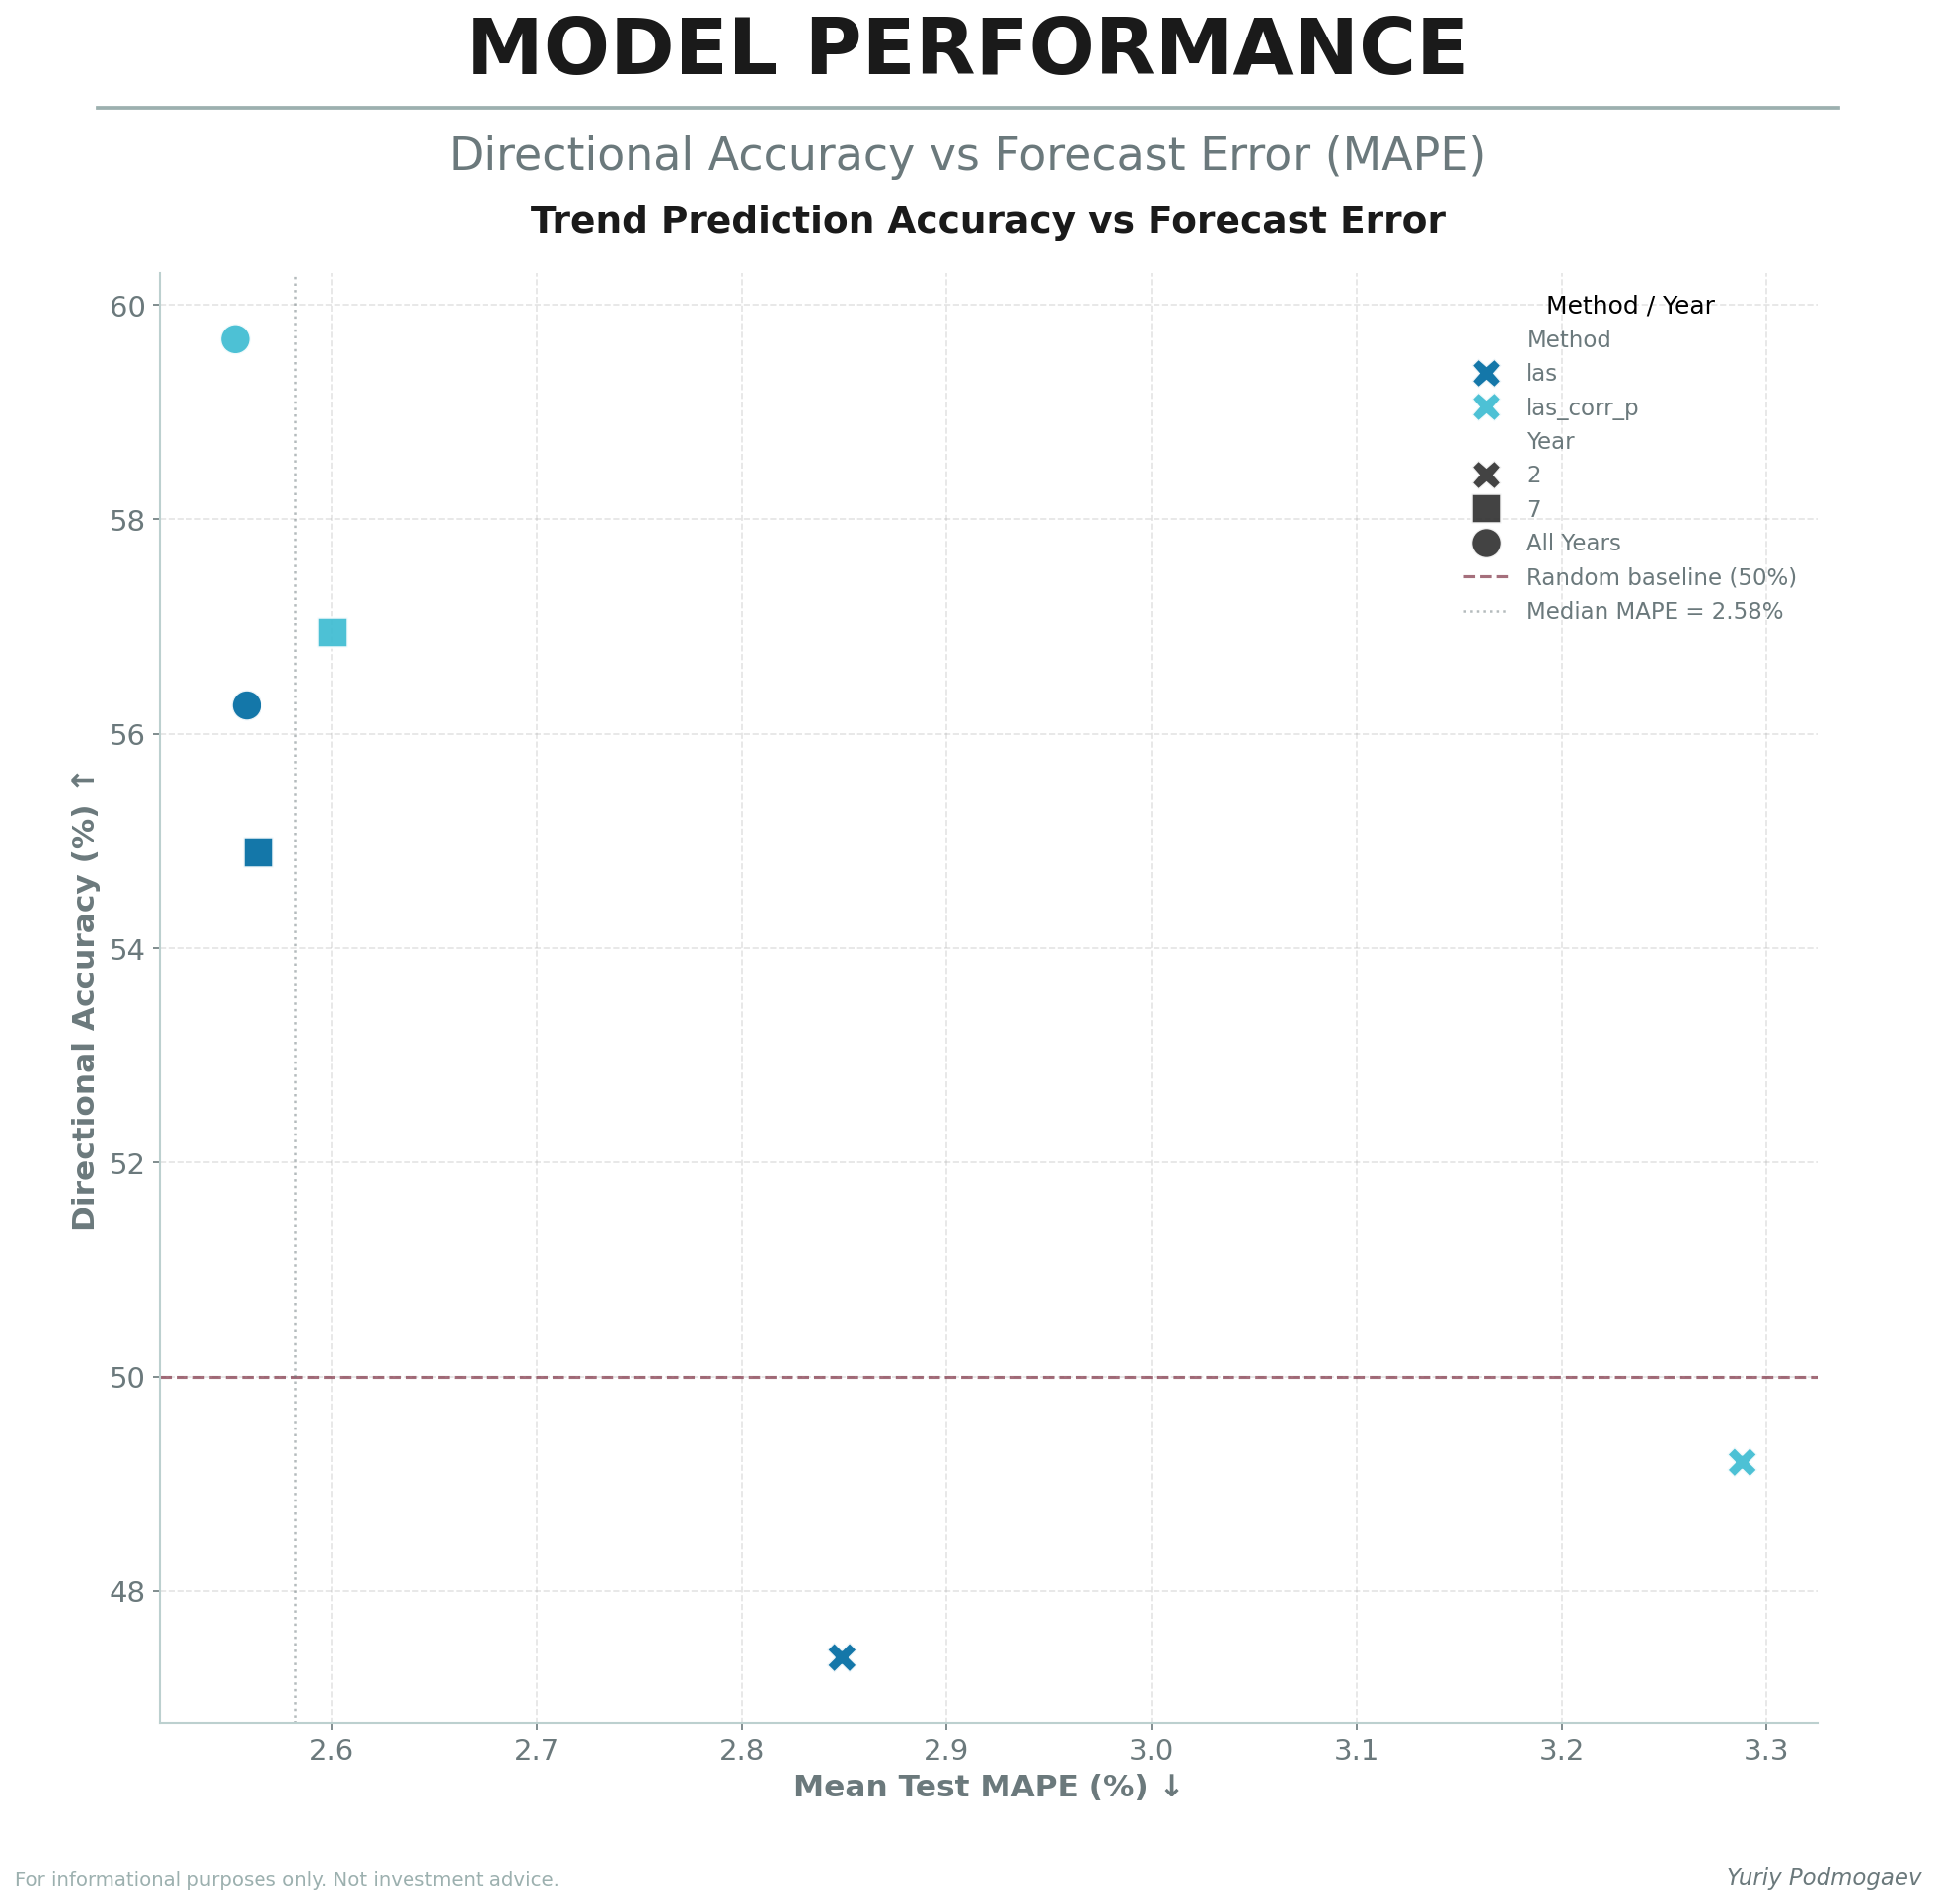

In [20]:
"""
Model Performance Analysis Module

This module extracts model evaluation metrics from Excel files and generates
visualizations comparing trend prediction accuracy against forecast error.
"""

import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

# ============================================================================
# CONSTANTS
# ============================================================================

# Brand color palette (20 unique professional colors)
BRAND_DATA_COLORS = [
    '#006BA2',  # Blue (primary)
    '#3EBCD2',  # Teal
    '#E7AA6D',  # Ochre
    '#7F3245',  # Crimson
    '#E09C99',  # Pink
    '#6B797C',  # Dark Gray
    '#4A7C59',  # Forest Green
    '#8FBC8F',  # Sage Green
    '#5D5C61',  # Charcoal
    '#7395AE',  # Dusty Blue
    '#557A95',  # Steel Blue
    '#B5838D',  # Dusty Rose
    '#E5989B',  # Light Rose
    '#6D6875',  # Muted Purple
    '#8A5A44',  # Brown
    '#D4A373',  # Tan
    '#9CB0AF',  # Medium Gray
    '#BCD0CF',  # Light Gray
    '#2B2D42',  # Dark Navy
    '#B5A8A0'   # Warm Gray
]

FONT_FAMILY = 'DejaVu Sans'

# ============================================================================
# DATA EXTRACTION FUNCTIONS
# ============================================================================


def normalize_depth(value: str) -> str:
    """
    Normalize training depth values to standard format.
    
    Args:
        value: Raw depth value (e.g., '2', '7', 'all', 'all years')
        
    Returns:
        Normalized depth value ('2', '7', or 'All Years')
    """
    value = str(value).strip().lower()
    if value in ['2', '7']:
        return value
    elif value in ['all', 'all years']:
        return 'All Years'
    else:
        return value


def extract_model_metrics(
    base_dir: Path,
    save_dir: Optional[Path] = None
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Extract model performance metrics from Excel files in method folders.
    
    Args:
        base_dir: Base directory containing method folders
        save_dir: Optional directory to save processed data
        
    Returns:
        Tuple of (summary DataFrame, list of found method names)
    """
    if save_dir is None:
        save_dir = base_dir / "plots"
    save_dir.mkdir(parents=True, exist_ok=True)
    
    print("🔍 Scanning method folders...")
    summary_records = []
    all_found_methods = []
    
    for folder in base_dir.iterdir():
        if not folder.is_dir() or folder.name.startswith('.'):
            continue
        
        method_name = folder.name
        print(f"  → Processing method: {method_name}")
        all_found_methods.append(method_name)
        
        results_path = folder / "results_df.xlsx"
        if not results_path.exists():
            print(f"    ⚠️ results_df.xlsx not found, skipping")
            continue
        
        df_res = pd.read_excel(results_path)
        metric_files = list(folder.glob("METRICS_DF_*.xlsx"))
        
        if not metric_files:
            continue
        
        for m_file in metric_files:
            match = re.search(r"METRICS_DF_([^\.]+)\.xlsx", m_file.name)
            if not match:
                continue
                
            config_val = match.group(1).strip()
            
            # Parse configuration: depth and parameter
            if '_' in config_val:
                parts = config_val.split('_', 1)
                depth_raw = parts[0]
                param_val = parts[1]
            else:
                depth_raw = config_val
                param_val = '-'
            
            year_val = normalize_depth(depth_raw)
                
            # Case-insensitive column search
            suffix = f"_{config_val}"
            pred_col = None
            for col in df_res.columns:
                if col.lower().endswith(suffix.lower()):
                    pred_col = col
                    break
            
            if not pred_col:
                continue
            
            # Calculate trend accuracy
            df_temp = df_res[['pr', 'pr_next', pred_col]].dropna().copy()
            df_temp = df_temp[df_temp['pr_next'].abs() > 1e-8]
            
            if len(df_temp) < 2:
                continue
                
            fact_dir = np.sign(df_temp['pr_next'] - df_temp['pr'])
            pred_dir = np.sign(df_temp[pred_col] - df_temp['pr'])
            trend_accuracy = np.mean(fact_dir == pred_dir) * 100
            
            # Extract metrics
            df_met = pd.read_excel(m_file)
            median_train_r2 = (
                df_met['Train_R2'].median() 
                if 'Train_R2' in df_met.columns 
                else np.nan
            )
            median_test_r2 = (
                df_met['Test_R2'].median() 
                if 'Test_R2' in df_met.columns 
                else np.nan
            )
            
            if pd.notna(median_train_r2) and pd.notna(median_test_r2):
                r2_gap = np.abs(median_train_r2 - median_test_r2)
            else:
                r2_gap = np.nan
                
            mean_test_mape = (
                df_met['Test_MAPE'].mean() 
                if 'Test_MAPE' in df_met.columns 
                else np.nan
            )
            
            # Calculate alpha volatility
            alpha_file = folder / f"ALPHA_DF_{config_val}.xlsx"
            alpha_vol = np.nan
            
            if alpha_file.exists():
                df_alpha = pd.read_excel(alpha_file)
                if 'Alpha' in df_alpha.columns and len(df_alpha) > 1:
                    alpha_mean = df_alpha['Alpha'].mean()
                    alpha_std = df_alpha['Alpha'].std()
                    alpha_vol = alpha_std / (alpha_mean + 1e-8)
            
            summary_records.append({
                'Method': method_name,
                'Year': year_val,
                'Param': param_val,
                'Test_MAPE_Mean': mean_test_mape,
                'Trend_Accuracy_Pct': trend_accuracy,
                'Median_Train_R2': median_train_r2,
                'Median_Test_R2': median_test_r2,
                'R2_Stability_Gap': r2_gap,
                'Alpha_Volatility': alpha_vol
            })
    
    df_summary = pd.DataFrame(summary_records)
    
    # Merge training time data if available
    log_file = base_dir / "df_time_log.xlsx"
    if log_file.exists():
        df_time = pd.read_excel(log_file)
        
        for col in ['Year', 'Param']:
            if col in df_summary.columns:
                df_summary[col] = df_summary[col].astype(str)
            if col in df_time.columns:
                df_time[col] = df_time[col].astype(str)
        
        merge_cols = {'Method': 'Marker', 'Time_perf': 'Time_min'}
        df_time_renamed = df_time.rename(
            columns={
                k: v for k, v in merge_cols.items() 
                if k in df_summary.columns and v in df_time.columns
            }
        )
        
        if ('Marker' in df_time_renamed.columns and 
            'Time_min' in df_time_renamed.columns):
            df_summary = pd.merge(
                df_summary, 
                df_time_renamed[['Marker', 'Year', 'Param', 'Time_min']], 
                left_on=['Method', 'Year', 'Param'], 
                right_on=['Marker', 'Year', 'Param'], 
                how='left'
            ).drop(columns=['Marker'])
        print("✓ Training time merged")
    
    print(f"✅ Complete! Collected {len(df_summary)} configurations")
    return df_summary, all_found_methods


# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================


def setup_plot_style():
    """Configure matplotlib plot style with brand settings."""
    plt.rcParams.update({
        'font.family': FONT_FAMILY,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'axes.edgecolor': '#BCD0CF',
        'axes.linewidth': 1.0,
        'axes.grid': False,
        'xtick.color': '#6B797C',
        'ytick.color': '#6B797C',
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'axes.labelsize': 15,
        'axes.labelcolor': '#6B797C',
        'axes.titlesize': 18,
        'axes.titlecolor': '#1A1A1A',
        'axes.titleweight': 'bold',
        'axes.titlepad': 16,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'legend.frameon': False,
        'legend.fontsize': 11,
        'legend.labelcolor': '#6B797C',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.facecolor': 'white',
    })


def add_figure_header(
    fig: plt.Figure,
    title: str,
    subtitle: str = ''
):
    """
    Add branded header to figure.
    
    Args:
        fig: Matplotlib figure
        title: Main title text
        subtitle: Optional subtitle text
    """
    fig.text(
        0.5, 0.915, title,
        ha='center', va='top',
        fontsize=38, fontweight='bold',
        color='#1A1A1A', fontfamily=FONT_FAMILY
    )
    
    y_line = 0.870
    fig.add_artist(
        plt.Line2D(
            [0.08, 0.92], [y_line, y_line],
            transform=fig.transFigure,
            color='#9CB0AF', linewidth=1.8
        )
    )
    
    if subtitle:
        fig.text(
            0.5, y_line - 0.013, subtitle,
            ha='center', va='top',
            fontsize=22, color='#6B797C',
            fontfamily=FONT_FAMILY
        )


def add_figure_footer(
    fig: plt.Figure,
    author: str = 'Yuriy Podmogaev'
):
    """
    Add branded footer to figure.
    
    Args:
        fig: Matplotlib figure
        author: Author name for footer
    """
    fig.text(
        0.04, 0.010,
        'For informational purposes only. Not investment advice.',
        ha='left', va='bottom',
        fontsize=9.5, color='#9CB0AF'
    )
    fig.text(
        0.96, 0.010, author,
        ha='right', va='bottom',
        fontsize=11, color='#6B797C', style='italic'
    )


def generate_method_palette(
    df: pd.DataFrame,
    method_col: str = 'Method'
) -> Dict[str, str]:
    """
    Generate color palette for methods.
    
    Args:
        df: DataFrame containing method column
        method_col: Name of method column
        
    Returns:
        Dictionary mapping method names to colors
    """
    unique_methods = sorted(df[method_col].dropna().unique().astype(str))
    palette = {
        method: BRAND_DATA_COLORS[i % len(BRAND_DATA_COLORS)]
        for i, method in enumerate(unique_methods)
    }
    return palette


def plot_trend_vs_mape(
    df: pd.DataFrame,
    global_palette: Dict[str, str],
    save_path: Optional[Path] = None
) -> Tuple[plt.Figure, plt.Axes]:
    """
    Create scatter plot of trend accuracy vs MAPE.
    
    Args:
        df: DataFrame with model performance metrics
        global_palette: Color palette for methods
        save_path: Optional path to save figure
        
    Returns:
        Tuple of (figure, axes)
    """
    fig, ax = plt.subplots(figsize=(14, 14))
    fig.subplots_adjust(left=0.11, right=0.91, top=0.79, bottom=0.09)
    
    add_figure_header(
        fig,
        'MODEL PERFORMANCE',
        'Directional Accuracy vs Forecast Error (MAPE)'
    )
    add_figure_footer(fig)
    
    sns.scatterplot(
        data=df,
        x='Test_MAPE_Mean',
        y='Trend_Accuracy_Pct',
        hue='Method',
        style='Year',
        markers={
            'All Years': 'o',
            '7': 's',
            '2': 'X'
        },
        s=220,
        palette=global_palette,
        edgecolor='white',
        linewidth=1.2,
        alpha=0.92,
        ax=ax
    )
    
    ax.axhline(
        y=50, color='#7F3245',
        linestyle='--', linewidth=1.5, alpha=0.7,
        label='Random baseline (50%)'
    )
    
    median_mape = df['Test_MAPE_Mean'].median()
    if pd.notna(median_mape):
        ax.axvline(
            x=median_mape, color='#6B797C',
            linestyle=':', linewidth=1.2, alpha=0.5,
            label=f'Median MAPE = {median_mape:.2f}%'
        )
    
    ax.set_title(
        'Trend Prediction Accuracy vs Forecast Error',
        fontweight='bold', pad=20
    )
    ax.set_xlabel('Mean Test MAPE (%) ↓', fontweight='semibold')
    ax.set_ylabel('Directional Accuracy (%) ↑', fontweight='semibold')
    
    ax.legend(
        loc='best', frameon=False,
        title='Method / Year',
        fontsize=11, title_fontsize=12
    )
    
    ax.grid(True, linestyle='--', alpha=0.35, axis='both', zorder=0)
    ax.set_axisbelow(True)
    
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, facecolor='white')
        print(f"✓ Figure saved: {save_path}")
    
    plt.show()
    return fig, ax


# ============================================================================
# MAIN EXECUTION
# ============================================================================


def main():
    """Main execution function."""
    # Configuration
    base_dir = Path(r"C:\Users\User1\Desktop\All_new\GIT\feature_selection\results")
    save_dir = base_dir / "plots"
    
    # Extract metrics
    df_summary, all_found_methods = extract_model_metrics(base_dir, save_dir)
    
    if len(df_summary) == 0:
        print("⚠️ No data collected. Exiting.")
        return
    
    # Check for base Lasso
    methods_lower = [m.strip().lower() for m in all_found_methods]
    has_base_lasso = any(m in ['las', 'lasso', 'base_lasso'] for m in methods_lower)
    
    if not has_base_lasso:
        print("⚠️ Base Lasso not found. Adding placeholder row.")
        new_row = {
            'Method': 'las',
            'Year': 'All Years',
            'Param': '-',
            'Test_MAPE_Mean': 15.0,
            'Trend_Accuracy_Pct': 52.0,
            'Median_Train_R2': 0.45,
            'Median_Test_R2': 0.40,
            'R2_Stability_Gap': 0.05,
            'Alpha_Volatility': 0.1
        }
        df_summary = pd.concat(
            [df_summary, pd.DataFrame([new_row])],
            ignore_index=True
        )
    else:
        las_in_summary = df_summary[
            df_summary['Method'].astype(str).str.lower() == 'las'
        ]
        if len(las_in_summary) > 0:
            print(f"✓ Base Lasso loaded: {len(las_in_summary)} configurations.")
        else:
            print("⚠️ Lasso folder found but no data extracted.")
    
    # Setup and generate visualization
    setup_plot_style()
    global_method_palette = generate_method_palette(df_summary)
    print(f"✓ Palette generated for {len(global_method_palette)} methods.")
    
    plot_trend_vs_mape(
        df_summary,
        global_palette=global_method_palette,
        save_path=save_dir / "01_trend_accuracy_vs_mape.png"
    )


if __name__ == "__main__":
    main()